<a href="https://colab.research.google.com/github/vijaydevverse/eda-ml-projects/blob/main/PriceCommodityPriceEdaV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/wb_commodity_price_intelligence_1960_2026.csv')
df

,date,year,month,commodity_name,price_nominal_usd,unit,category,source_desc,data_source,dataset_version,...,price_3m_avg,price_12m_avg,price_60m_avg,price_12m_volatility,price_index_2000_base,is_all_time_high,is_all_time_low,price_regime_mom,commodity_code,row_completeness_pct
0,1960-01-01,1960,1,Aluminum,511.471832,($/mt),Fertilizers,"Aluminum (LME) London Metal Exchange, unalloye...",World Bank Pink Sheet,1.0,...,511.4718,NaN,NaN,NaN,30.44,1,1,Unknown,ALUM,100.0
1,1960-02-01,1960,2,Aluminum,511.471832,($/mt),Fertilizers,"Aluminum (LME) London Metal Exchange, unalloye...",World Bank Pink Sheet,1.0,...,511.4718,NaN,NaN,NaN,30.44,1,1,Stable,ALUM,100.0
2,1960-03-01,1960,3,Aluminum,511.471832,($/mt),Fertilizers,"Aluminum (LME) London Metal Exchange, unalloye...",World Bank Pink Sheet,1.0,...,511.4718,511.4718,NaN,NaN,30.44,1,1,Stable,ALUM,100.0
3,1960-04-01,1960,4,Aluminum,511.471832,($/mt),Fertilizers,"Aluminum (LME) London Metal Exchange, unalloye...",World Bank Pink Sheet,1.0,...,511.4718,511.4718,NaN,NaN,30.44,1,1,Stable,ALUM,100.0
4,1960-05-01,1960,5,Aluminum,511.471832,($/mt),Fertilizers,"Aluminum (LME) London Metal Exchange, unalloye...",World Bank Pink Sheet,1.0,...,511.4718,511.4718,NaN,NaN,30.44,1,1,Stable,ALUM,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49088,2024-08-01,2024,8,Zinc,2714.080000,($/mt),Fertilizers,"Zinc (LME), high grade, minimum 99.95% purity,...",World Bank Pink Sheet,1.0,...,2766.8467,2609.9183,2794.0937,181.9579,230.24,0,0,Falling,ZINC,100.0
49089,2024-09-01,2024,9,Zinc,2837.020000,($/mt),Fertilizers,"Zinc (LME), high grade, minimum 99.95% purity,...",World Bank Pink Sheet,1.0,...,2776.1233,2638.3783,2802.5180,189.0068,240.67,0,0,Rising,ZINC,100.0
49090,2024-10-01,2024,10,Zinc,3105.770000,($/mt),Fertilizers,"Zinc (LME), high grade, minimum 99.95% purity,...",World Bank Pink Sheet,1.0,...,2885.6233,2693.1458,2813.4200,221.4394,263.47,0,0,Sharp Rise,ZINC,100.0
49091,2024-11-01,2024,11,Zinc,3004.200000,($/mt),Fertilizers,"Zinc (LME), high grade, minimum 99.95% purity,...",World Bank Pink Sheet,1.0,...,2982.3300,2731.5283,2823.0653,232.7903,254.85,0,0,Falling,ZINC,100.0


In [ ]:
df.isnull().sum()

,0
date,0
year,0
month,0
commodity_name,0
price_nominal_usd,0
unit,0
category,0
source_desc,4882
data_source,0
dataset_version,80


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49093 entries, 0 to 49092
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   49093 non-null  object 
 1   year                   49093 non-null  int64  
 2   month                  49093 non-null  int64  
 3   commodity_name         49093 non-null  object 
 4   price_nominal_usd      49093 non-null  float64
 5   unit                   49093 non-null  object 
 6   category               49093 non-null  object 
 7   source_desc            44211 non-null  object 
 8   data_source            49093 non-null  object 
 9   dataset_version        49013 non-null  float64
 10  retrieved_date         49013 non-null  object 
 11  build_timestamp        49013 non-null  object 
 12  month_name             49093 non-null  object 
 13  quarter                49093 non-null  object 
 14  decade                 49093 non-null  object 
 15  er

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(49093, 29)

In [ ]:
df=df.drop(['source_desc','commodity_code','price_60m_avg','price_index_2000_base'],axis=1)

In [ ]:
df['price_mom_pct']=df['price_mom_pct'].fillna(df['price_mom_pct'].mean())
df['price_yoy_pct']=df['price_yoy_pct'].fillna(df['price_yoy_pct'].mean())
df['price_mom_abs']=df['price_mom_abs'].fillna(df['price_mom_abs'].mean())
df['price_12m_avg']=df['price_12m_avg'].fillna(df['price_12m_avg'].mean())
df['price_12m_volatility']=df['price_12m_volatility'].fillna(df['price_12m_volatility'].mean())

In [ ]:
df=df.dropna(subset=['dataset_version','retrieved_date','build_timestamp'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49013 entries, 0 to 49092
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  49013 non-null  object 
 1   year                  49013 non-null  int64  
 2   month                 49013 non-null  int64  
 3   commodity_name        49013 non-null  object 
 4   price_nominal_usd     49013 non-null  float64
 5   unit                  49013 non-null  object 
 6   category              49013 non-null  object 
 7   data_source           49013 non-null  object 
 8   dataset_version       49013 non-null  float64
 9   retrieved_date        49013 non-null  object 
 10  build_timestamp       49013 non-null  object 
 11  month_name            49013 non-null  object 
 12  quarter               49013 non-null  object 
 13  decade                49013 non-null  object 
 14  era                   49013 non-null  object 
 15  price_mom_pct         49

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['commodity_name']=le.fit_transform(df['commodity_name'])
df['unit']=le.fit_transform(df['unit'])
df['category']=le.fit_transform(df['category'])
df['data_source']=le.fit_transform(df['data_source'])
df['month_name']=le.fit_transform(df['month_name'])
df['quarter']=le.fit_transform(df['quarter'])
df['decade']=le.fit_transform(df['decade'])
df['era']=le.fit_transform(df['era'])
df['price_regime_mom']=le.fit_transform(df['price_regime_mom'])

In [ ]:
df["price_regime_mom"].replace(["Falling","Stable","Rising","Sharp Rise"],[0,1,2,3],inplace=True)

/tmp/ipykernel_16387/1430536619.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["price_regime_mom"].replace(["Falling","Stable","Rising","Sharp Rise"],[0,1,2,3],inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 49013 entries, 1960-01-01 to 2024-12-01
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  49013 non-null  int64  
 1   month                 49013 non-null  int64  
 2   commodity_name        49013 non-null  int64  
 3   price_nominal_usd     49013 non-null  float64
 4   unit                  49013 non-null  int64  
 5   category              49013 non-null  int64  
 6   data_source           49013 non-null  int64  
 7   dataset_version       49013 non-null  float64
 8   month_name            49013 non-null  int64  
 9   quarter               49013 non-null  int64  
 10  decade                49013 non-null  int64  
 11  era                   49013 non-null  int64  
 12  price_mom_pct         49013 non-null  float64
 13  price_yoy_pct         49013 non-null  float64
 14  price_mom_abs         49013 non-null  float64
 15  pr

In [ ]:
df=df.drop(['retrieved_date','build_timestamp'],axis=1)

In [ ]:
df['date']=pd.to_datetime(df['date'])
df.set_index('date',inplace=True)

In [ ]:
df

,year,month,commodity_name,price_nominal_usd,unit,category,data_source,dataset_version,month_name,quarter,...,price_mom_pct,price_yoy_pct,price_mom_abs,price_3m_avg,price_12m_avg,price_12m_volatility,is_all_time_high,is_all_time_low,price_regime_mom,row_completeness_pct
date,,,,,,,,,,,,,,,,,,,,,
1960-01-01,1960,1,0,511.471832,5,2,0,1.0,4,0,...,0.534744,7.512365,1.677431,511.4718,650.179539,66.450096,1,1,5,100.0
1960-02-01,1960,2,0,511.471832,5,2,0,1.0,3,0,...,0.000000,7.512365,0.000000,511.4718,650.179539,66.450096,1,1,4,100.0
1960-03-01,1960,3,0,511.471832,5,2,0,1.0,7,0,...,0.000000,7.512365,0.000000,511.4718,511.471800,66.450096,1,1,4,100.0
1960-04-01,1960,4,0,511.471832,5,2,0,1.0,0,1,...,0.000000,7.512365,0.000000,511.4718,511.471800,66.450096,1,1,4,100.0
1960-05-01,1960,5,0,511.471832,5,2,0,1.0,8,1,...,0.000000,7.512365,0.000000,511.4718,511.471800,66.450096,1,1,4,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,2024,8,70,2714.080000,5,2,0,1.0,1,2,...,-2.275300,12.770900,-63.190000,2766.8467,2609.918300,181.957900,0,0,0,100.0
2024-09-01,2024,9,70,2837.020000,5,2,0,1.0,11,2,...,4.529700,13.685400,122.940000,2776.1233,2638.378300,189.006800,0,0,1,100.0
2024-10-01,2024,10,70,3105.770000,5,2,0,1.0,10,3,...,9.473000,26.840700,268.750000,2885.6233,2693.145800,221.439400,0,0,3,100.0


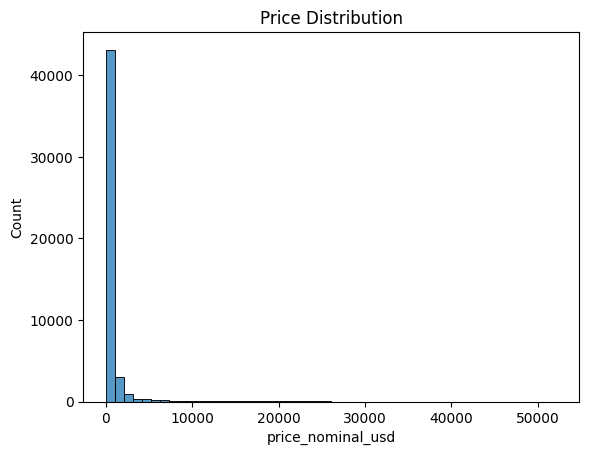

In [ ]:
plt.figure()
sns.histplot(df['price_nominal_usd'],bins=50)
plt.title("Price Distribution")
plt.show()

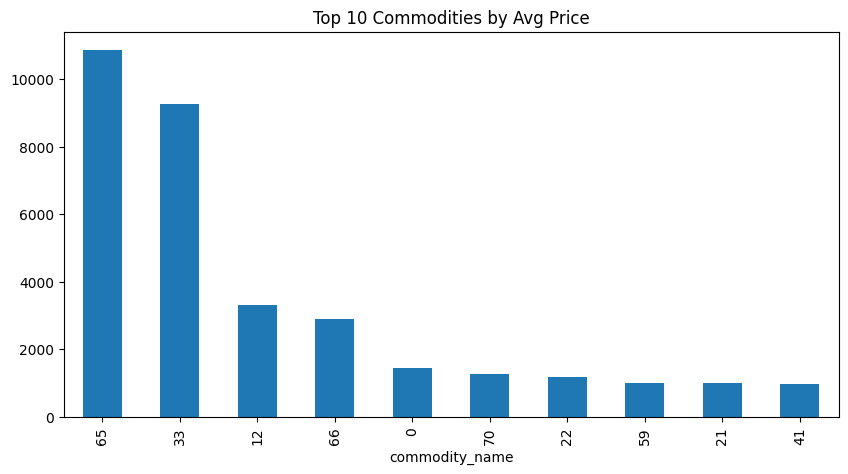

In [ ]:
top=df.groupby('commodity_name')['price_nominal_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top.plot(kind='bar')
plt.title("Top 10 Commodities by Avg Price")
plt.show()

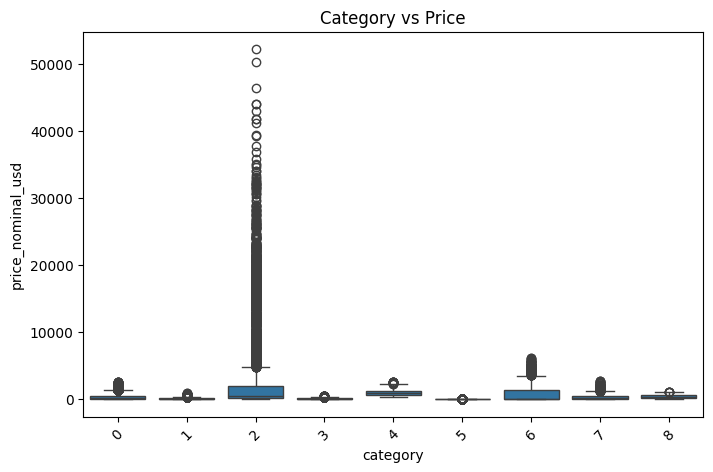

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='category',y='price_nominal_usd',data=df)
plt.xticks(rotation=45)
plt.title("Category vs Price")
plt.show()

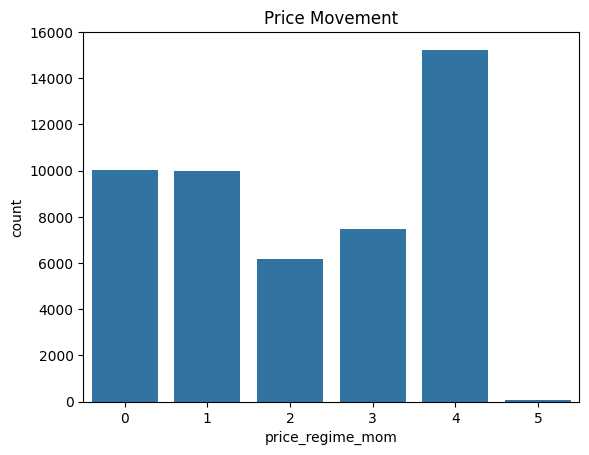

In [ ]:
sns.countplot(x='price_regime_mom',data=df)
plt.title("Price Movement")
plt.show()

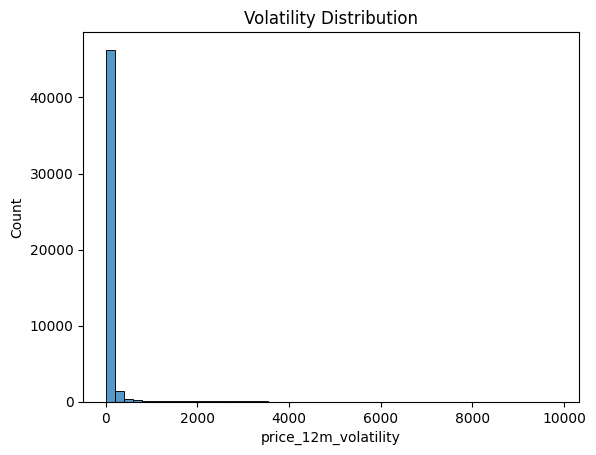

In [ ]:
plt.figure()
sns.histplot(df['price_12m_volatility'],bins=50)
plt.title("Volatility Distribution")
plt.show()

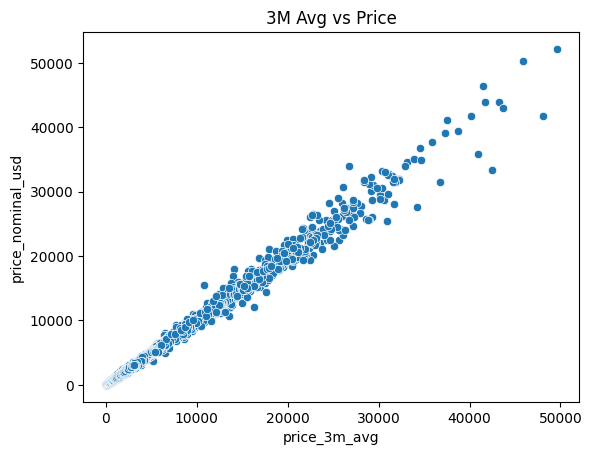

In [ ]:
plt.figure()
sns.scatterplot(x='price_3m_avg',y='price_nominal_usd',data=df)
plt.title("3M Avg vs Price")
plt.show()

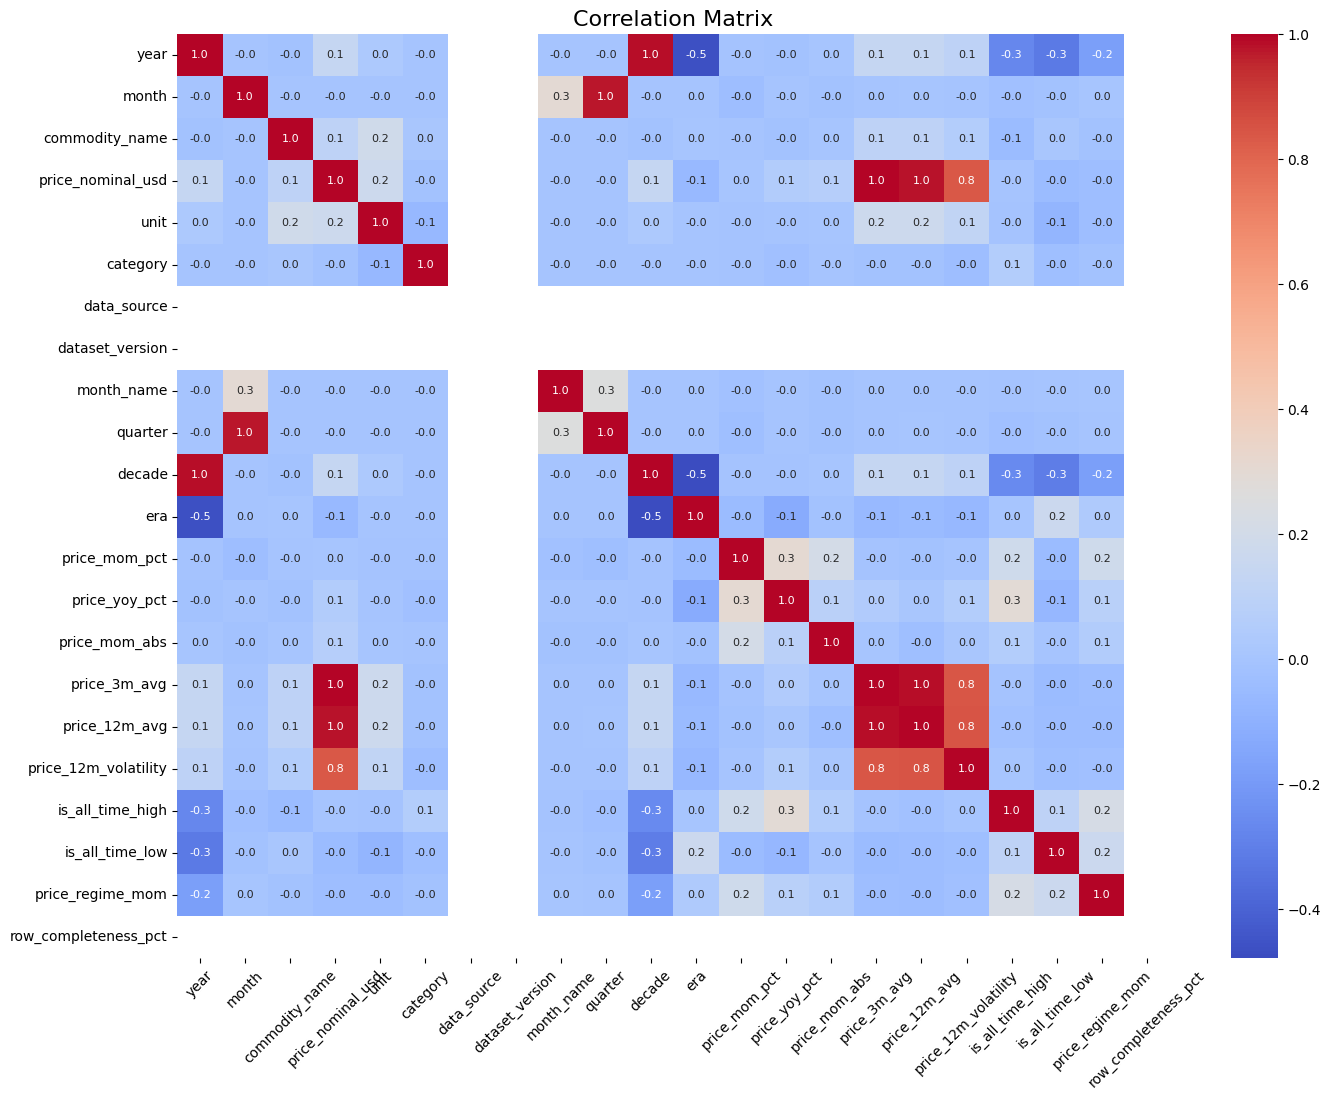

In [ ]:
plt.figure(figsize=(16,12))
cm=df.corr(numeric_only=True)
sns.heatmap(cm,annot=True,fmt=".1f",cmap="coolwarm",annot_kws={"size":8})
plt.title("Correlation Matrix",fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [ ]:
df.drop(['row_completeness_pct','dataset_version'],axis=1,inplace=True)

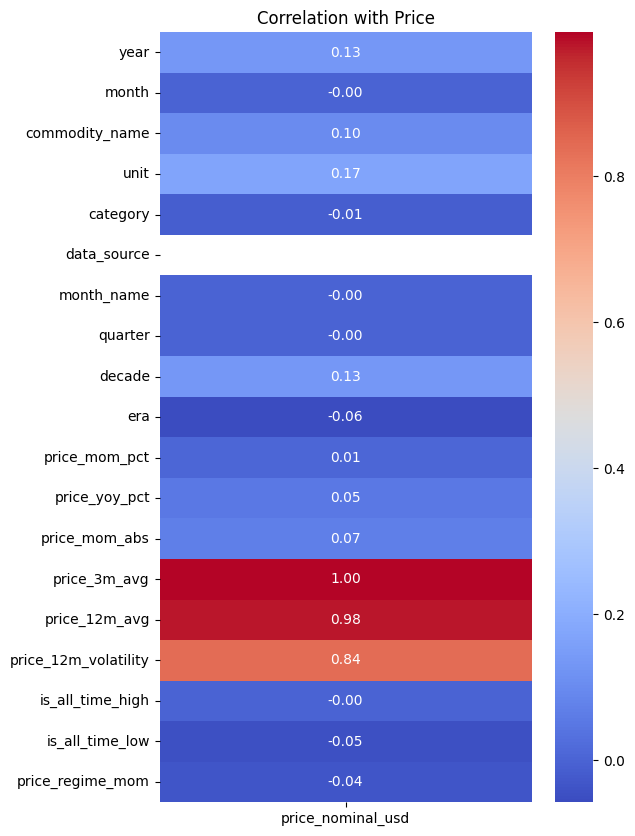

In [ ]:
corr=df.corr(numeric_only=True)['price_nominal_usd']
corr=corr.drop('price_nominal_usd')

plt.figure(figsize=(6,10))
sns.heatmap(corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',cbar=True,annot_kws={'size':10})
plt.title('Correlation with Price')
plt.show()

<Axes: >

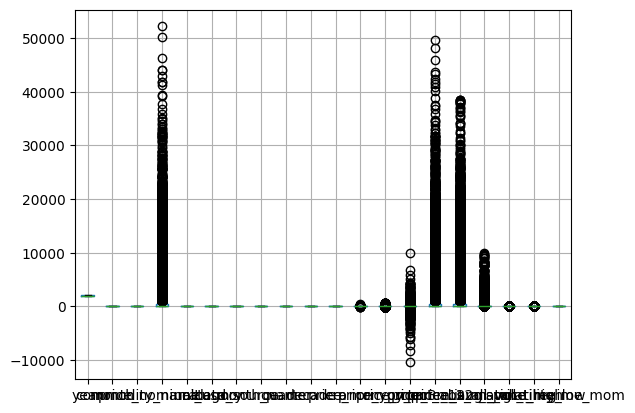

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR
        df=df[(df[col]>=lower) & (df[col]<=upper)]
    return df

df=remove_outliers_iqr(df,exclude_column='price_nominal_usd')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7687 entries, 1997-08-01 to 2024-11-01
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  7687 non-null   int64  
 1   month                 7687 non-null   int64  
 2   commodity_name        7687 non-null   int64  
 3   price_nominal_usd     7687 non-null   float64
 4   unit                  7687 non-null   int64  
 5   category              7687 non-null   int64  
 6   data_source           7687 non-null   int64  
 7   month_name            7687 non-null   int64  
 8   quarter               7687 non-null   int64  
 9   decade                7687 non-null   int64  
 10  era                   7687 non-null   int64  
 11  price_mom_pct         7687 non-null   float64
 12  price_yoy_pct         7687 non-null   float64
 13  price_mom_abs         7687 non-null   float64
 14  price_3m_avg          7687 non-null   float64
 15  pri

In [ ]:
df.shape

(7687, 20)

In [ ]:
df

,year,month,commodity_name,price_nominal_usd,unit,category,data_source,month_name,quarter,decade,era,price_mom_pct,price_yoy_pct,price_mom_abs,price_3m_avg,price_12m_avg,price_12m_volatility,is_all_time_high,is_all_time_low,price_regime_mom
date,,,,,,,,,,,,,,,,,,,,
1997-08-01,1997,8,1,0.921990,3,3,0,1,2,3,3,0.7309,7.512365,0.0067,0.8787,0.9566,0.0900,0,0,4
1997-10-01,1997,10,1,1.051540,3,3,0,10,3,3,3,-2.5829,7.512365,-0.0279,1.0176,0.9783,0.0919,0,0,0
1997-11-01,1997,11,1,0.974970,3,3,0,9,3,3,3,-7.2817,7.512365,-0.0766,1.0353,0.9780,0.0872,0,0,2
1998-02-01,1998,2,1,0.968420,3,3,0,3,0,3,3,-4.7225,-0.475800,-0.0480,0.9475,0.9743,0.0905,0,0,0
1998-03-01,1998,3,1,1.029650,3,3,0,7,0,3,3,6.3227,-7.186100,0.0612,1.0048,0.9677,0.0822,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-01,2024,6,64,3.222120,3,0,0,6,1,6,0,0.8317,19.581100,0.0266,3.1505,2.8220,0.2241,0,0,4
2024-07-01,2024,7,64,3.295540,3,0,0,5,2,6,0,2.2786,33.600900,0.0734,3.2377,2.8911,0.2322,0,0,1
2024-08-01,2024,8,64,3.224870,3,0,0,1,2,6,0,-2.1444,13.753500,-0.0707,3.2475,2.9236,0.2502,0,0,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['year','month','commodity_name','price_nominal_usd','unit','category','data_source','price_mom_pct','price_yoy_pct','price_mom_abs','price_3m_avg','price_12m_avg','price_12m_volatility','is_all_time_high','is_all_time_low','price_regime_mom']

scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import pandas as pd

x=df[['year','month','commodity_name','unit','category','data_source',
      'price_mom_pct','price_yoy_pct','price_mom_abs',
      'price_3m_avg','price_12m_avg','price_12m_volatility',
      'is_all_time_high','is_all_time_low','price_regime_mom']]

y=df[['price_nominal_usd']]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

score=model.score(x_test,y_test)
print(f'Baseline model r2 Score: {score:.2f}')

Baseline model r2 Score: 1.00
